# Melakukan Klasifikasi Dengan LDA


In [33]:
!pip install plotly

In [2]:
!pip install -q nltk contractions emoji pyspellchecker Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00


In [3]:
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 9.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 

In [96]:
import re
import sys
import time
import string
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from spellchecker import SpellChecker
import contractions
import emoji
from gensim.models import Word2Vec, FastText
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Crawling Berita

In [4]:
def berita(categories, pages_per_category=1):
    start_time = time.time()  # mulai hitung waktu

    BASE_URL = "https://www.tempo.co/indeks?page={}&category=rubrik&rubric_slug={}"

    data = {
        "id_berita": [],
        "judul_berita": [],
        "isi_berita": [],
        "kategori_berita": []
    }

    for cat_id, cat in enumerate(categories, start=1):
        for page in range(1, pages_per_category+1):
            url = BASE_URL.format(page, cat)
            r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
            soup = BeautifulSoup(r.text, "html.parser")

            articles = soup.select("figure figcaption a")
            for a in articles:
                link = "https://www.tempo.co" + a["href"]
                title = a.get_text(strip=True)

                id_match = re.search(r"-(\d+)$", link)
                berita_id = id_match.group(1) if id_match else None

                try:
                    content = get_article_content(link)
                except:
                    content = ""

                data["id_berita"].append(berita_id)
                data["judul_berita"].append(title)
                data["isi_berita"].append(content)
                data["kategori_berita"].append(cat)

            print_progress2(cat, page, pages_per_category)

    df = pd.DataFrame(data)
    df.to_csv("tempo_berita.csv", index=False, encoding="utf-8-sig")

    end_time = time.time()
    elapsed = int(end_time - start_time)
    jam, sisa = divmod(elapsed, 3600)
    menit, detik = divmod(sisa, 60)

    # summary
    print("\n✅ Seluruh data berhasil dikumpulkan!")
    print(f"📊 Total entri: {len(df)}")
    print(f"⏱️ Waktu eksekusi: {jam} jam {menit} menit {detik} detik")

    return None

In [5]:
berita = pd.read_csv("tempo_berita.csv")
berita

,id_berita,judul_berita,isi_berita,kategori_berita
0,2068663,Kronologi Mundurnya Rahayu Saraswati dari DPR,RAHAYU SaraswatiDjojohadikusumo mengumumkan pe...,politik
1,2068660,Kata Wapres Gibran soal Reshuffle Kabinet,WAKIL PresidenGibran Rakabumingmeresponsreshuf...,politik
2,2068655,Kata Staf Khusus Gubernur Jakarta soal Tanggul...,TANGGUL beton yang disebut memiliki panjang 2 ...,politik
3,2068650,Empat Nama Mencuat dalam Bursa Calon Sekda Kab...,"BURSA calon Sekretaris DaerahKabupaten Bekasi,...",politik
4,2068644,Top 3 Nasional: Klarifikasi Purbaya hingga Rah...,TIGA berita di kanal politik Tempo mendapat so...,politik
...,...,...,...,...
895,2066177,Tangisan Antony Usai Pergi dari Manchester Uni...,PEMAIN sepak bola asal BrasilAntonymenangis sa...,sepakbola
896,2066151,Jadwal Siaran Langsung Timnas U-23 Indonesia d...,TIMNAS U-23 Indonesia akan memulai laga babakK...,sepakbola
897,2066144,Pesan Alexander Isak kepada Newcastle Usai Sag...,PEMAIN sepak bolaAlexander Isakberterima kasih...,sepakbola
898,2066121,Prediksi Indonesia vs Laos di Kualifikasi Pial...,DUEL Timnas U-23Indonesia vs Laosakan tersaji ...,sepakbola


## Fungsi cleaning dengan emoji


In [6]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()  # huruf kecil
    text = emoji.demojize(text)  # ubah emoji jadi teks, misal 😀 -> :grinning_face:
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = re.sub(r'\W', ' ', text)  # hapus karakter non-kata
    text = BeautifulSoup(text, "html.parser").get_text()  # hapus tag HTML
    text = re.sub(r'\s+', ' ', text).strip()  # normalisasi spasi
    return text

# Baca CSV
tempo_df = pd.read_csv("tempo_berita.csv", dtype=str).fillna("")

# Terapkan langsung ke kolom target
tempo_df["isi_berita_clean"] = tempo_df["isi_berita"].apply(clean_text)

# Cleaning kolom target
tempo_df["isi_berita_clean"] = tempo_df["isi_berita"].apply(clean_text)

In [7]:
print("\nBerita (tempo_berita):")
tempo_df[["isi_berita", "isi_berita_clean"]].head(10)


Berita (tempo_berita):


,isi_berita,isi_berita_clean
0,RAHAYU SaraswatiDjojohadikusumo mengumumkan pe...,rahayu saraswatidjojohadikusumo mengumumkan pe...
1,WAKIL PresidenGibran Rakabumingmeresponsreshuf...,wakil presidengibran rakabumingmeresponsreshuf...
2,TANGGUL beton yang disebut memiliki panjang 2 ...,tanggul beton yang disebut memiliki panjang hi...
3,"BURSA calon Sekretaris DaerahKabupaten Bekasi,...",bursa calon sekretaris daerahkabupaten bekasi ...
4,TIGA berita di kanal politik Tempo mendapat so...,tiga berita di kanal politik tempo mendapat so...
5,Pilihan Editor:Pemerintah Bayari Iuran BPJS Ke...,pilihan editorpemerintah bayari iuran bpjs ket...
6,KOALISI Sipil mengusulkan sedikitnya lima isu ...,koalisi sipil mengusulkan sedikitnya lima isu ...
7,POLITIKUS Partai GerindraRahayu SaraswatiDjojo...,politikus partai gerindrarahayu saraswatidjojo...
8,POLITIKUS PartaiGerindraRahayu SaraswatiDjojoh...,politikus partaigerindrarahayu saraswatidjojoh...
9,MENTERI KeuanganPurbayaYudhi Sadewa menanggapi...,menteri keuanganpurbayayudhi sadewa menanggapi...


In [8]:
# Tokenisasi untuk PTA
tempo_df["isi_berita_tokens"] = tempo_df["isi_berita_clean"].apply(word_tokenize)

In [9]:
print("\nBerita (isi_berita_tokens):")
tempo_df[["isi_berita_clean", "isi_berita_tokens"]].head(10)


Berita (isi_berita_tokens):


,isi_berita_clean,isi_berita_tokens
0,rahayu saraswatidjojohadikusumo mengumumkan pe...,"[rahayu, saraswatidjojohadikusumo, mengumumkan..."
1,wakil presidengibran rakabumingmeresponsreshuf...,"[wakil, presidengibran, rakabumingmeresponsres..."
2,tanggul beton yang disebut memiliki panjang hi...,"[tanggul, beton, yang, disebut, memiliki, panj..."
3,bursa calon sekretaris daerahkabupaten bekasi ...,"[bursa, calon, sekretaris, daerahkabupaten, be..."
4,tiga berita di kanal politik tempo mendapat so...,"[tiga, berita, di, kanal, politik, tempo, mend..."
5,pilihan editorpemerintah bayari iuran bpjs ket...,"[pilihan, editorpemerintah, bayari, iuran, bpj..."
6,koalisi sipil mengusulkan sedikitnya lima isu ...,"[koalisi, sipil, mengusulkan, sedikitnya, lima..."
7,politikus partai gerindrarahayu saraswatidjojo...,"[politikus, partai, gerindrarahayu, saraswatid..."
8,politikus partaigerindrarahayu saraswatidjojoh...,"[politikus, partaigerindrarahayu, saraswatidjo..."
9,menteri keuanganpurbayayudhi sadewa menanggapi...,"[menteri, keuanganpurbayayudhi, sadewa, menang..."


## Stopwords

In [32]:
# Stopwords untuk bahasa Indonesia
stop_words_id = set(stopwords.words('indonesian'))

# Filter stopwords di PTA
tempo_df["isi_berita_filtered"] = tempo_df["isi_berita_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words_id]
)

In [11]:
print("\nBerita (isi_berita_filtered):")
tempo_df[["isi_berita_tokens", "isi_berita_filtered"]].head(10)


Berita (isi_berita_filtered):


,isi_berita_tokens,isi_berita_filtered
0,"[rahayu, saraswatidjojohadikusumo, mengumumkan...","[rahayu, saraswatidjojohadikusumo, mengumumkan..."
1,"[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres..."
2,"[tanggul, beton, yang, disebut, memiliki, panj...","[tanggul, beton, memiliki, kilometer, muncul, ..."
3,"[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be..."
4,"[tiga, berita, di, kanal, politik, tempo, mend...","[berita, kanal, politik, tempo, sorotan, pemba..."
5,"[pilihan, editorpemerintah, bayari, iuran, bpj...","[pilihan, editorpemerintah, bayari, iuran, bpj..."
6,"[koalisi, sipil, mengusulkan, sedikitnya, lima...","[koalisi, sipil, mengusulkan, isu, dibahas, de..."
7,"[politikus, partai, gerindrarahayu, saraswatid...","[politikus, partai, gerindrarahayu, saraswatid..."
8,"[politikus, partaigerindrarahayu, saraswatidjo...","[politikus, partaigerindrarahayu, saraswatidjo..."
9,"[menteri, keuanganpurbayayudhi, sadewa, menang...","[menteri, keuanganpurbayayudhi, sadewa, menang..."


In [12]:
factory = StemmerFactory()
indo_stemmer = factory.create_stemmer()

tempo_df["isi_berita_stemmed"] = tempo_df["isi_berita_filtered"].apply(
    lambda tokens: [indo_stemmer.stem(word) for word in tokens]
)

In [13]:
print("\nBerita - Stemming & Lemmatization (abstrak_id):")
tempo_df[["isi_berita_filtered", "isi_berita_stemmed"]].head(10)


Berita - Stemming & Lemmatization (abstrak_id):


,isi_berita_filtered,isi_berita_stemmed
0,"[rahayu, saraswatidjojohadikusumo, mengumumkan...","[rahayu, saraswatidjojohadikusumo, umum, undur..."
1,"[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres..."
2,"[tanggul, beton, memiliki, kilometer, muncul, ...","[tanggul, beton, milik, kilometer, muncul, pes..."
3,"[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be..."
4,"[berita, kanal, politik, tempo, sorotan, pemba...","[berita, kanal, politik, tempo, sorot, baca, s..."
5,"[pilihan, editorpemerintah, bayari, iuran, bpj...","[pilih, editorpemerintah, bayar, iur, bpjs, ke..."
6,"[koalisi, sipil, mengusulkan, isu, dibahas, de...","[koalisi, sipil, usul, isu, bahas, dewan, waki..."
7,"[politikus, partai, gerindrarahayu, saraswatid...","[politikus, partai, gerindrarahayu, saraswatid..."
8,"[politikus, partaigerindrarahayu, saraswatidjo...","[politikus, partaigerindrarahayu, saraswatidjo..."
9,"[menteri, keuanganpurbayayudhi, sadewa, menang...","[menteri, keuanganpurbayayudhi, sadewa, tangga..."


## Fungsi expand kontraksi bahasa Indonesia


In [14]:
def expand_indonesian_contractions(text):
  contractions_dict = {
      "gak": "tidak", "ga": "tidak", "nggak": "tidak", "enggak": "tidak", "ngga": "tidak", "gk": "tidak", "tdk": "tidak", "tk": "tidak",
      "gue": "saya", "gw": "saya", "gua": "saya", "sy": "saya", "aq": "saya", "q": "saya", "ane": "saya",
      "lu": "kamu", "loe": "kamu", "lo": "kamu", "km": "kamu", "kmu": "kamu", "elu": "kamu",
      "dah": "sudah", "udah": "sudah", "sdh": "sudah", "udh": "sudah",
      "blm": "belum", "td": "tadi", "ntar": "nanti", "skr": "sekarang", "skrg": "sekarang", "skg": "sekarang",
      "kmrn": "kemarin", "kemrn": "kemarin", "kmarin": "kemarin",
      "aja": "saja", "aj": "saja", "sj": "saja",
      "nih": "ini", "nie": "ini", "ni": "ini", "tuh": "itu", "gtu": "begitu", "gitu": "begitu",
      "trs": "terus", "trus": "terus",
      "yg": "yang", "utk": "untuk", "dlm": "dalam", "dr": "dari", "dg": "dengan", "jd": "jadi", "jg": "juga",
      "krn": "karena", "tp": "tetapi", "tpi": "tetapi", "sm": "sama", "thd": "terhadap",
      "dll": "dan lain-lain", "dsb": "dan sebagainya", "dst": "dan seterusnya",
      "banget": "sekali", "bgt": "sekali", "sgt": "sangat", "sngt": "sangat",
      "lg": "sedang", "sdg": "sedang",
      "dl": "dulu", "pls": "tolong", "tolongin": "tolong", "plis": "tolong",
      "wkwk": "tertawa", "wkwkwk": "tertawa", "hehe": "tertawa kecil", "hihi": "tertawa kecil",
      "btw": "ngomong-ngomong", "imo": "menurut saya", "imho": "menurut saya", "cmiiw": "koreksi jika saya salah",
      "idk": "saya tidak tahu", "jk": "hanya bercanda",
      "ok": "baik", "oke": "baik", "okey": "baik", "sip": "baik",
      "ciyus": "serius", "serem": "menyeramkan",
      "kl": "kalau", "klo": "kalau", "klu": "kalau",
      "spy": "supaya", "spya": "supaya",
      "bbrp": "beberapa", "tsb": "tersebut", "trsbt": "tersebut",
      "dpt": "dapat", "bs": "bisa", "bsa": "bisa",
      "stlh": "setelah", "sblm": "sebelum",

      "mnj": "manajemen", "man": "manajemen", "mgt": "management",
      "org": "organisasi", "org2": "organisasi", "orgzt": "organisasi",
      "str": "struktur", "stkt": "struktur",
      "ldr": "leader", "ldrshp": "leadership", "pimp": "pimpinan", "pemimp": "pemimpin",
      "pln": "perencanaan", "renc": "perencanaan", "plan": "perencanaan",
      "orgz": "organizing", "orgzn": "organisasi",
      "dir": "directing", "pgn": "pengarahan",
      "cnt": "control", "cont": "control", "ctrl": "kontrol", "pengend": "pengendalian",
      "eff": "efisiensi", "effct": "efektivitas",
      "sdm": "sumber daya manusia", "hr": "human resource", "hrd": "human resource development",
      "res": "resource", "rsc": "resource", "sda": "sumber daya alam",
      "inv": "investasi", "invt": "investasi",
      "pmas": "pemasaran", "mkt": "marketing", "mktg": "marketing",
      "prod": "produksi", "prdks": "produksi",
      "fin": "finance", "keu": "keuangan", "akut": "akuntansi", "acct": "akuntansi",
      "ris": "risiko", "rsko": "risiko",
      "anal": "analisis", "eval": "evaluasi",
      "strtg": "strategi", "stg": "strategi",
      "ops": "operasi", "opr": "operasional", "oprs": "operasional",
      "bsc": "balanced scorecard", "swot": "analisis swot", "pest": "analisis pest",
      "csr": "corporate social responsibility", "gcn": "good corporate governance",
      "qm": "quality management", "iso": "standar iso",
      "kpi": "key performance indicator", "indik": "indikator",
      "knowl": "knowledge management", "kmgt": "knowledge management",
      "chg": "change management", "innv": "inovasi",
      "cnfl": "konflik", "cnflt": "konflik",
      "krj": "kerja", "tm": "tim", "tmwrk": "kerja sama tim",
      "cst": "cost", "faktorfaktor": "faktor", "bya": "biaya",
      "val": "nilai", "valu": "value",
      "proj": "proyek", "prjk": "proyek",

      "med": "medis", "obat2": "obat-obatan", "rs": "rumah sakit",
      "dok": "dokter", "drg": "dokter gigi", "prof": "profesor",
      "pt": "perguruan tinggi", "univ": "universitas", "fak": "fakultas",
      "skripsi": "skripsi", "tesis": "tesis", "disertasi": "disertasi",
      "mhs": "mahasiswa", "mhsw": "mahasiswa"
  }


  pattern = r'\b(' + '|'.join(re.escape(key) for key in contractions_dict.keys()) + r')\b'

  def replace_match(match):
      return contractions_dict[match.group(0).lower()]

  expanded_text = re.sub(pattern, replace_match, text, flags=re.IGNORECASE)
  return expanded_text


tempo_df["isi_berita_expanded"] = tempo_df["isi_berita_stemmed"].apply(
    lambda tokens: expand_indonesian_contractions(" ".join(tokens)).split()
)


In [15]:
print("\nBerita - Isi berita (expanded):")
tempo_df[["isi_berita_stemmed", "isi_berita_expanded"]].head(10)


Berita - Isi berita (expanded):


,isi_berita_stemmed,isi_berita_expanded
0,"[rahayu, saraswatidjojohadikusumo, umum, undur...","[rahayu, saraswatidjojohadikusumo, umum, undur..."
1,"[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres..."
2,"[tanggul, beton, milik, kilometer, muncul, pes...","[tanggul, beton, milik, kilometer, muncul, pes..."
3,"[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be..."
4,"[berita, kanal, politik, tempo, sorot, baca, s...","[berita, kanal, politik, tempo, sorot, baca, s..."
5,"[pilih, editorpemerintah, bayar, iur, bpjs, ke...","[pilih, editorpemerintah, bayar, iur, bpjs, ke..."
6,"[koalisi, sipil, usul, isu, bahas, dewan, waki...","[koalisi, sipil, usul, isu, bahas, dewan, waki..."
7,"[politikus, partai, gerindrarahayu, saraswatid...","[politikus, partai, gerindrarahayu, saraswatid..."
8,"[politikus, partaigerindrarahayu, saraswatidjo...","[politikus, partaigerindrarahayu, saraswatidjo..."
9,"[menteri, keuanganpurbayayudhi, sadewa, tangga...","[menteri, keuanganpurbayayudhi, sadewa, tangga..."


In [16]:
# Inisialisasi SpellChecker kosong
spell = SpellChecker(language=None)

# Load kamus Indonesia dari file
with open("00-indonesian-wordlist.lst", "r", encoding="latin-1") as f:
    indo_words = [line.strip() for line in f.readlines()]

spell.word_frequency.load_words(indo_words)

# Fungsi untuk koreksi kata
def correct_word(word):
    corr = spell.correction(word)
    return corr if corr is not None else word

# Terapkan spellcheck ke setiap baris dengan progress bar
corrected_texts = []
for tokens in tqdm(tempo_df["isi_berita_expanded"], desc="Spellchecking", unit="row"):
    corrected = [correct_word(word) for word in tokens]
    corrected_texts.append(corrected)

tempo_df["isi_berita_spellchecked"] = corrected_texts

Spellchecking: 100%|██████████| 900/900 [3:25:52<00:00, 13.73s/row]


In [18]:
print("\nBerita (Cek Ejaan):")
tempo_df[["isi_berita_expanded", "isi_berita_spellchecked"]].head(10)


Berita (Cek Ejaan):


,isi_berita_expanded,isi_berita_spellchecked
0,"[rahayu, saraswatidjojohadikusumo, umum, undur...","[rahayu, saraswatidjojohadikusumo, umum, undur..."
1,"[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres..."
2,"[tanggul, beton, milik, kilometer, muncul, pes...","[tanggul, beton, milik, kilometer, muncul, pes..."
3,"[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be..."
4,"[berita, kanal, politik, tempo, sorot, baca, s...","[berita, kanal, politik, tempo, sorot, baca, s..."
5,"[pilih, editorpemerintah, bayar, iur, bpjs, ke...","[pilih, editorpemerintah, bayar, iur, bps, ket..."
6,"[koalisi, sipil, usul, isu, bahas, dewan, waki...","[koalisi, sipil, usul, isu, bahas, dewan, waki..."
7,"[politikus, partai, gerindrarahayu, saraswatid...","[politikus, partai, gerindrarahayu, saraswatid..."
8,"[politikus, partaigerindrarahayu, saraswatidjo...","[politikus, partaigerindrarahayu, saraswatidjo..."
9,"[menteri, keuanganpurbayayudhi, sadewa, tangga...","[menteri, keuanganpurbayayudhi, sadewa, tangga..."


## Pilih kolom yang ingin disimpan

In [21]:
cols_to_save = [
    "id_berita",
    "judul_berita",
    "isi_berita",
    "kategori_berita",
    "isi_berita_clean",
    "isi_berita_tokens",
    "isi_berita_filtered",
    "isi_berita_stemmed",
    "isi_berita_expanded",
    "isi_berita_spellchecked"
]

# Simpan ke CSV
tempo_df[cols_to_save].to_csv("tempo_processed.csv", index=False, encoding="utf-8-sig")

print("File berhasil disimpan sebagai tempo_processed.csv")


File berhasil disimpan sebagai tempo_processed.csv


In [23]:
tempo_df_prs= pd.read_csv("tempo_processed.csv")
tempo_df_prs

,id_berita,judul_berita,isi_berita,kategori_berita,isi_berita_clean,isi_berita_tokens,isi_berita_filtered,isi_berita_stemmed,isi_berita_expanded,isi_berita_spellchecked
0,2068663,Kronologi Mundurnya Rahayu Saraswati dari DPR,RAHAYU SaraswatiDjojohadikusumo mengumumkan pe...,politik,rahayu saraswatidjojohadikusumo mengumumkan pe...,"['rahayu', 'saraswatidjojohadikusumo', 'mengum...","['rahayu', 'saraswatidjojohadikusumo', 'mengum...","['rahayu', 'saraswatidjojohadikusumo', 'umum',...","['rahayu', 'saraswatidjojohadikusumo', 'umum',...","['rahayu', 'saraswatidjojohadikusumo', 'umum',..."
1,2068660,Kata Wapres Gibran soal Reshuffle Kabinet,WAKIL PresidenGibran Rakabumingmeresponsreshuf...,politik,wakil presidengibran rakabumingmeresponsreshuf...,"['wakil', 'presidengibran', 'rakabumingmerespo...","['wakil', 'presidengibran', 'rakabumingmerespo...","['wakil', 'presidengibran', 'rakabumingmerespo...","['wakil', 'presidengibran', 'rakabumingmerespo...","['wakil', 'presidengibran', 'rakabumingmerespo..."
2,2068655,Kata Staf Khusus Gubernur Jakarta soal Tanggul...,TANGGUL beton yang disebut memiliki panjang 2 ...,politik,tanggul beton yang disebut memiliki panjang hi...,"['tanggul', 'beton', 'yang', 'disebut', 'memil...","['tanggul', 'beton', 'memiliki', 'kilometer', ...","['tanggul', 'beton', 'milik', 'kilometer', 'mu...","['tanggul', 'beton', 'milik', 'kilometer', 'mu...","['tanggul', 'beton', 'milik', 'kilometer', 'mu..."
3,2068650,Empat Nama Mencuat dalam Bursa Calon Sekda Kab...,"BURSA calon Sekretaris DaerahKabupaten Bekasi,...",politik,bursa calon sekretaris daerahkabupaten bekasi ...,"['bursa', 'calon', 'sekretaris', 'daerahkabupa...","['bursa', 'calon', 'sekretaris', 'daerahkabupa...","['bursa', 'calon', 'sekretaris', 'daerahkabupa...","['bursa', 'calon', 'sekretaris', 'daerahkabupa...","['bursa', 'calon', 'sekretaris', 'daerahkabupa..."
4,2068644,Top 3 Nasional: Klarifikasi Purbaya hingga Rah...,TIGA berita di kanal politik Tempo mendapat so...,politik,tiga berita di kanal politik tempo mendapat so...,"['tiga', 'berita', 'di', 'kanal', 'politik', '...","['berita', 'kanal', 'politik', 'tempo', 'sorot...","['berita', 'kanal', 'politik', 'tempo', 'sorot...","['berita', 'kanal', 'politik', 'tempo', 'sorot...","['berita', 'kanal', 'politik', 'tempo', 'sorot..."
...,...,...,...,...,...,...,...,...,...,...
895,2066177,Tangisan Antony Usai Pergi dari Manchester Uni...,PEMAIN sepak bola asal BrasilAntonymenangis sa...,sepakbola,pemain sepak bola asal brasilantonymenangis sa...,"['pemain', 'sepak', 'bola', 'asal', 'brasilant...","['pemain', 'sepak', 'bola', 'brasilantonymenan...","['main', 'sepak', 'bola', 'brasilantonymenangi...","['main', 'sepak', 'bola', 'brasilantonymenangi...","['main', 'sepak', 'bola', 'brasilantonymenangi..."
896,2066151,Jadwal Siaran Langsung Timnas U-23 Indonesia d...,TIMNAS U-23 Indonesia akan memulai laga babakK...,sepakbola,timnas u indonesia akan memulai laga babakkual...,"['timnas', 'u', 'indonesia', 'akan', 'memulai'...","['timnas', 'u', 'indonesia', 'laga', 'babakkua...","['timnas', 'u', 'indonesia', 'laga', 'babakkua...","['timnas', 'u', 'indonesia', 'laga', 'babakkua...","['timnas', 'u', 'indonesia', 'laga', 'babakkua..."
897,2066144,Pesan Alexander Isak kepada Newcastle Usai Sag...,PEMAIN sepak bolaAlexander Isakberterima kasih...,sepakbola,pemain sepak bolaalexander isakberterima kasih...,"['pemain', 'sepak', 'bolaalexander', 'isakbert...","['pemain', 'sepak', 'bolaalexander', 'isakbert...","['main', 'sepak', 'bolaalexander', 'isakberter...","['main', 'sepak', 'bolaalexander', 'isakberter...","['main', 'sepak', 'bolaalexander', 'isakberter..."
898,2066121,Prediksi Indonesia vs Laos di Kualifikasi Pial...,DUEL Timnas U-23Indonesia vs Laosakan tersaji ...,sepakbola,duel timnas uindonesia vs laosakan tersaji pad...,"['duel', 'timnas', 'uindonesia', 'vs', 'laosak...","['duel', 'timnas', 'uindonesia', 'vs', 'laosak...","['duel', 'timnas', 'uindonesia', 'vs', 'laosak...","['duel', 'timnas', 'uindonesia',

## Hitung frekuensi kemunculan setiap kata

In [27]:
from collections import Counter
import numpy as np
all_tokens = [word for tokens in tempo_df["isi_berita_spellchecked"] for word in tokens]

# Hitung frekuensi kemunculan setiap kata
word_freq = Counter(all_tokens)

# Ambil 20 kata yang paling sering muncul
common_words = word_freq.most_common(10)

print("=== 10 Kata Terbanyak ===")
for word, freq in common_words:
    print(f"{word} : {freq}")

# Informasi tambahan
total_words = len(all_tokens)                       # jumlah total kata
unique_words = len(word_freq)                       # jumlah kata unik
avg_word_len = np.mean([len(word) for word in all_tokens])  # rata-rata panjang kata
avg_words_per_data = np.mean([len(tokens) for tokens in tempo_df["isi_berita_spellchecked"]])  # rata-rata kata per data
longest_word = max(all_tokens, key=len)             # kata terpanjang
longest_word_len = len(longest_word)

print("\n=== Statistik Tambahan ===")
print(f"Jumlah total kata       : {total_words}")
print(f"Jumlah kata unik        : {unique_words}")
print(f"Rata-rata panjang kata  : {avg_word_len:.2f} karakter")
print(f"Rata-rata kata per data : {avg_words_per_data:.2f} kata")


=== 10 Kata Terbanyak ===
indonesia : 1614
september : 1422
main : 1272
menteri : 1168
pilih : 1051
balap : 770
negara : 722
perintah : 706
jalan : 705
tim : 650

=== Statistik Tambahan ===
Jumlah total kata       : 207341
Jumlah kata unik        : 15625
Rata-rata panjang kata  : 5.93 karakter
Rata-rata kata per data : 230.38 kata


## Konversi hasil frekuensi kata ke DataFrame

In [28]:
word_freq_df = pd.DataFrame(word_freq.items(), columns=["kata", "jumlah"])

# Urutkan berdasarkan jumlah kemunculan kata (dari terbesar ke terkecil)
word_freq_df = word_freq_df.sort_values(by="jumlah", ascending=False).reset_index(drop=True)

# Simpan hasil ke file CSV
word_freq_df.to_csv("tempo_word_frequency.csv", index=False, encoding="utf-8-sig")

print("\nFile berhasil disimpan sebagai tempo_word_frequency.csv.")



File berhasil disimpan sebagai tempo_word_frequency.csv.


## TF-IDF

In [35]:
tempo_df_wfq = pd.read_csv("tempo_word_frequency.csv")
print(tempo_df_wfq.head(10))

        kata  jumlah
0  indonesia    1614
1  september    1422
2       main    1272
3    menteri    1168
4      pilih    1051
5      balap     770
6     negara     722
7   perintah     706
8      jalan     705
9        tim     650


In [36]:
df = pd.read_csv('tempo_word_frequency.csv')

In [38]:
print(tempo_df.columns)

Index(['id_berita', 'judul_berita', 'isi_berita', 'kategori_berita',
       'isi_berita_clean', 'isi_berita_tokens', 'isi_berita_filtered',
       'isi_berita_stemmed', 'isi_berita_expanded', 'isi_berita_spellchecked'],
      dtype='object')


## Membuat TF-IDF Vectorizer

In [42]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(tempo_df['isi_berita_clean'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [43]:
print("\nTF-IDF shape:", tfidf_df.shape)
print(tfidf_df.head())


TF-IDF shape: (900, 23148)
    aa  aamiin  aanwijzing  aarhus  aaron  aas  abaaba  abad  abadi  abangku  \
0  0.0     0.0         0.0     0.0    0.0  0.0     0.0   0.0    0.0      0.0   
1  0.0     0.0         0.0     0.0    0.0  0.0     0.0   0.0    0.0      0.0   
2  0.0     0.0         0.0     0.0    0.0  0.0     0.0   0.0    0.0      0.0   
3  0.0     0.0         0.0     0.0    0.0  0.0     0.0   0.0    0.0      0.0   
4  0.0     0.0         0.0     0.0    0.0  0.0     0.0   0.0    0.0      0.0   

   ...  zoom  zubimendi  zuihoden  zulaikha  zulfikar  zulhas  zulkarnaen  \
0  ...   0.0        0.0       0.0       0.0       0.0     0.0         0.0   
1  ...   0.0        0.0       0.0       0.0       0.0     0.0         0.0   
2  ...   0.0        0.0       0.0       0.0       0.0     0.0         0.0   
3  ...   0.0        0.0       0.0       0.0       0.0     0.0         0.0   
4  ...   0.0        0.0       0.0       0.0       0.0     0.0         0.0   

   zulkifli  zverev  zwolle 

## Word Embedding

In [80]:
corpus = []
for col in tempo_df['isi_berita_clean']:
    word_list = col.split(" ")
    corpus.append(word_list)

# Word2Vec dengan ukuran vektor 50
model = Word2Vec(corpus, min_count=1, vector_size=50, window=5, sg=0)


In [82]:
print("Kata mirip dengan 'presiden':")
print(model.wv.most_similar('presiden', topn=5))

print("\nKata mirip dengan 'data':")
print(model.wv.most_similar('data', topn=5))

# contoh cosmul
print("\nCosmul (presiden + sistem - data):")
print(model.wv.most_similar_cosmul(positive=['presiden', 'sistem'], negative=['data'], topn=5))

# doesnt_match: cari kata yang tidak sesuai konteks
print("\nKata yang tidak cocok dalam ['presiden', 'data', 'sistem', 'informasi']:")
print(model.wv.doesnt_match("presiden data sistem informasi".split()))

# save embeddings
filename = 'pta_embeddings.txt'
model.wv.save_word2vec_format(filename, binary=False)
print(f"\nEmbeddings disimpan ke {filename}")

Kata mirip dengan 'presiden':
[('subianto', 0.9938076138496399), ('prabowo', 0.9843542575836182), ('widodo', 0.9743742346763611), ('dilantik', 0.968199610710144), ('menjabat', 0.9569506645202637)]

Kata mirip dengan 'data':
[('janice', 0.998199999332428), ('hotel', 0.9979801177978516), ('sesar', 0.9972874522209167), ('perdagangan', 0.9968382120132446), ('maksimum', 0.996752142906189)]

Cosmul (presiden + sistem - data):
[('prerogatif', 1.0068981647491455), ('widodo', 0.9919576048851013), ('menpora', 0.9919025301933289), ('menjabat', 0.9903536438941956), ('prabowo', 0.9880002737045288)]

Kata yang tidak cocok dalam ['presiden', 'data', 'sistem', 'informasi']:
presiden

Embeddings disimpan ke pta_embeddings.txt


In [83]:
class MyTokenizer:
    def fit_transform(self, texts):
        return [str(text).lower().split() for text in texts]

class MeanEmbeddingVectorizer:
    def __init__(self, word2vec_model):
        self.word2vec = word2vec_model
        self.dim = word2vec_model.wv.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_tokenized = MyTokenizer().fit_transform(X)
        embeddings = []
        for words in X_tokenized:
            valid_vectors = [
                self.word2vec.wv[word] for word in words
                if word in self.word2vec.wv
            ]
            if valid_vectors:
                embeddings.append(np.mean(valid_vectors, axis=0))
            else:
                embeddings.append(np.zeros(self.dim))
        return np.array(embeddings)

    def fit_transform(self, X, y=None):
        return self.transform(X)

In [84]:
tempo_df.shape

(900, 15)

In [85]:
tempo_df['tokens'] = tempo_df['isi_berita_clean'].apply(lambda x: str(x).split())
mean_embedding_vectorizer = MeanEmbeddingVectorizer(model)
mean_embedded = mean_embedding_vectorizer.fit_transform(tempo_df['tokens'])


In [87]:
tempo_df['array'] = list(mean_embedded)

In [88]:
tempo_df.head(10)

,id_berita,judul_berita,isi_berita,kategori_berita,isi_berita_clean,isi_berita_tokens,isi_berita_filtered,isi_berita_stemmed,isi_berita_expanded,isi_berita_spellchecked,isi_berita_vector,embedding,tokens,array,embedding_length
0,2068663,Kronologi Mundurnya Rahayu Saraswati dari DPR,RAHAYU SaraswatiDjojohadikusumo mengumumkan pe...,politik,rahayu saraswatidjojohadikusumo mengumumkan pe...,"[rahayu, saraswatidjojohadikusumo, mengumumkan...","[rahayu, saraswatidjojohadikusumo, mengumumkan...","[rahayu, saraswatidjojohadikusumo, umum, undur...","[rahayu, saraswatidjojohadikusumo, umum, undur...","[rahayu, saraswatidjojohadikusumo, umum, undur...","[-0.50332326, 0.15641461, 0.51342463, -0.75253...","[-0.09932058, 0.17000003, -0.061525397, 0.0258...","[rahayu, saraswatidjojohadikusumo, mengumumkan...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100
1,2068660,Kata Wapres Gibran soal Reshuffle Kabinet,WAKIL PresidenGibran Rakabumingmeresponsreshuf...,politik,wakil presidengibran rakabumingmeresponsreshuf...,"[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres...","[wakil, presidengibran, rakabumingmeresponsres...","[-0.3295427, 0.07140859, 0.4674911, -0.8695259...","[-0.20120716, 0.37025437, -0.1771595, 0.072695...","[wakil, presidengibran, rakabumingmeresponsres...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100
2,2068655,Kata Staf Khusus Gubernur Jakarta soal Tanggul...,TANGGUL beton yang disebut memiliki panjang 2 ...,politik,tanggul beton yang disebut memiliki panjang hi...,"[tanggul, beton, yang, disebut, memiliki, panj...","[tanggul, beton, memiliki, kilometer, muncul, ...","[tanggul, beton, milik, kilometer, muncul, pes...","[tanggul, beton, milik, kilometer, muncul, pes...","[tanggul, beton, milik, kilometer, muncul, pes...","[-0.48500124, 0.22638653, 0.48222443, -0.63304...","[-0.082044974, 0.24683662, -0.06290082, 0.2461...","[tanggul, beton, yang, disebut, memiliki, panj...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100
3,2068650,Empat Nama Mencuat dalam Bursa Calon Sekda Kab...,"BURSA calon Sekretaris DaerahKabupaten Bekasi,...",politik,bursa calon sekretaris daerahkabupaten bekasi ...,"[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be...","[bursa, calon, sekretaris, daerahkabupaten, be...","[-0.4603992, 0.22677262, 0.50541276, -0.634372...","[-0.20759386, 0.18033327, -0.002985986, 0.1178...","[bursa, calon, sekretaris, daerahkabupaten, be...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100
4,2068644,Top 3 Nasional: Klarifikasi Purbaya hingga Rah...,TIGA berita di kanal politik Tempo mendapat so...,politik,tiga berita di kanal politik tempo mendapat so...,"[tiga, berita, di, kanal, politik, tempo, mend...","[berita, kanal, politik, tempo, sorotan, pemba...","[berita, kanal, politik, tempo, sorot, baca, s...","[berita, kanal, politik, tempo, sorot, baca, s...","[berita, kanal, politik, tempo, sorot, baca, s...","[-0.48636428, 0.12847008, 0.49350274, -0.80156...","[-0.17358515, 0.22207534, -0.18791035, 0.04559...","[tiga, berita, di, kanal, politik, tempo, mend...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100
5,2068633,Penjelasan Sekda soal Bedol Desa ASN Purwakart...,Pilihan Editor:Pemerintah Bayari Iuran BPJS Ke...,politik,pilihan editorpemerintah bayari iuran bpjs ket...,"[pilihan, editorpemerintah, bayari, iuran, bpj...","[pilihan, editorpemerintah, bayari, iuran, bpj...","[pilih, editorpemerintah, bayar, iur, bpjs, ke...","[pilih, editorpemerintah, bayar, iur, bpjs, ke...","[pilih, editorpemerintah, bayar, iur, bps, ket...","[-0.4189788, 0.31073663, 0.54244035, -0.569871...","[-0.16609666, 0.20496497, 0.10258695, 0.118950...","[pilihan, editorpemerintah, bayari, iuran, bpj..."

In [89]:
tempo_df['embedding_length'] = tempo_df['array'].str.len()

In [90]:
print(tempo_df['embedding_length'])

0      50
1      50
2      50
3      50
4      50
       ..
895    50
896    50
897    50
898    50
899    50
Name: embedding_length, Length: 900, dtype: int64


In [92]:
tempo_df.shape

(900, 15)

In [93]:
num_features = len(tempo_df['array'].iloc[0])  # asumsi semua list punya panjang sama
columns = [f'f{i+1}' for i in range(num_features)]

# Inisialisasi dictionary untuk menampung data per kolom
data_dict = {col: [] for col in columns}

# Looping setiap baris di kolom 'embedding'
for embedding_list in tempo_df['array']:
    for i, value in enumerate(embedding_list):
        data_dict[f'f{i+1}'].append(value)

# Buat DataFrame dari dictionary
embedding_df = pd.DataFrame(data_dict)

print(embedding_df)

      f1   f2   f3   f4   f5   f6   f7   f8   f9  f10  ...  f41  f42  f43  \
0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
895  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
896  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
897  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
898  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
899  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

     f44  f45  f46  f47  f48  f49  f50  
0    0.0  0.0  0.0  0.0  0.0  0.0 

In [78]:
embedding_df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,f100
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Klasifikasi LDA

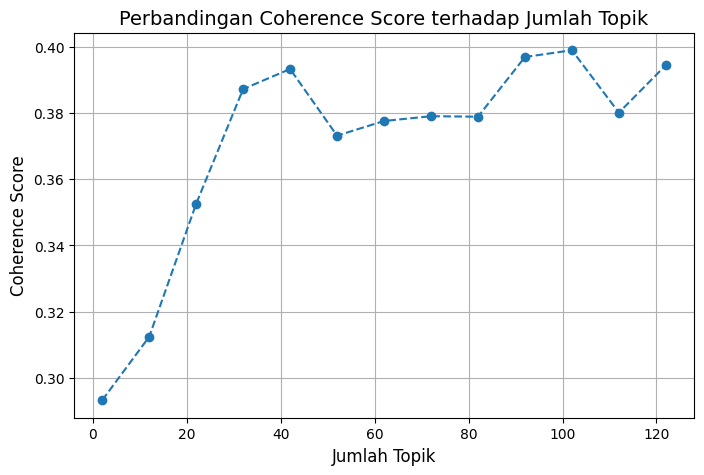

✅ Model terbaik memiliki 102 topik
Coherence Score terbaik: 0.39892290915768486


In [100]:
if 'isi_berita_tokens' not in tempo_df.columns:
    tempo_df['isi_berita_tokens'] = tempo_df['isi_berita_clean'].apply(lambda x: str(x).split())

# Dataset teks tokenized
texts = tempo_df['isi_berita_tokens']

# Buat dictionary dan corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# === Evaluasi jumlah topik optimal ===
coherence_values = []
model_list = []
topic_range = range(2, 130, 10)  # misalnya 2–120 topik

for num_topics in topic_range:
    model = LdaModel(
        corpus=corpus,
        num_topics=num_topics,
        id2word=dictionary,
        random_state=42,
        passes=10,
        iterations=100
    )
    model_list.append(model)
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

# === Visualisasi Coherence Score ===
plt.figure(figsize=(8, 5))
plt.plot(topic_range, coherence_values, marker='o', linestyle='--')
plt.xlabel("Jumlah Topik", fontsize=12)
plt.ylabel("Coherence Score", fontsize=12)
plt.title("Perbandingan Coherence Score terhadap Jumlah Topik", fontsize=14)
plt.grid(True)
plt.show()

# === Model terbaik ===
optimal_model = model_list[coherence_values.index(max(coherence_values))]
optimal_topics = topic_range[coherence_values.index(max(coherence_values))]

print("✅ Model terbaik memiliki", optimal_topics, "topik")
print("Coherence Score terbaik:", max(coherence_values))



In [101]:
for idx, topic in optimal_model.print_topics(-1):
    print(f"\nTopik {idx+1}: {topic}")


Topik 1: 0.008*"asia" + 0.008*"depan" + 0.007*"lima" + 0.006*"gemilang" + 0.006*"dan" + 0.006*"menit" + 0.005*"di" + 0.005*"gol" + 0.005*"dengan" + 0.005*"dua"

Topik 2: 0.032*"tuntutan" + 0.020*"yang" + 0.019*"dan" + 0.015*"rakyat" + 0.013*"di" + 0.012*"pada" + 0.011*"kota" + 0.011*"ekonomi" + 0.011*"sebagian" + 0.010*"itu"

Topik 3: 0.021*"yang" + 0.018*"pekerja" + 0.016*"di" + 0.016*"tambang" + 0.011*"dan" + 0.010*"terjebak" + 0.010*"area" + 0.009*"dalam" + 0.009*"para" + 0.009*"itu"

Topik 4: 0.029*"gibran" + 0.016*"di" + 0.014*"kata" + 0.012*"dan" + 0.010*"adrian" + 0.010*"lobster" + 0.010*"batam" + 0.009*"indonesia" + 0.009*"lafc" + 0.009*"budidaya"

Topik 5: 0.027*"di" + 0.019*"yang" + 0.018*"angin" + 0.017*"monsun" + 0.016*"dan" + 0.014*"september" + 0.014*"jawa" + 0.013*"erma" + 0.012*"cuaca" + 0.011*"bagian"

Topik 6: 0.070*"agung" + 0.050*"ketua" + 0.044*"ma" + 0.043*"hakim" + 0.030*"suara" + 0.026*"wakil" + 0.026*"mahkamah" + 0.025*"pemilihan" + 0.021*"nonyudisial" + 0.016

In [106]:
dominant_topics = []

for i, doc_bow in enumerate(corpus):
    topics_in_doc = optimal_model.get_document_topics(doc_bow, minimum_probability=0)
    topics_in_doc = sorted(topics_in_doc, key=lambda x: x[1], reverse=True)
    topic_num, prop = topics_in_doc[0]
    dominant_topics.append((topic_num + 1, round(prop, 3)))

df_dominant = pd.DataFrame(dominant_topics, columns=["Topik Dominan", "Proporsi"])

df_result = pd.concat([tempo_df.reset_index(drop=True), df_dominant.reset_index(drop=True)], axis=1)

display(df_result[["judul_berita", "kategori_berita", "Topik Dominan", "Proporsi", "isi_berita_clean"]])

,judul_berita,kategori_berita,Topik Dominan,Proporsi,isi_berita_clean
0,Kronologi Mundurnya Rahayu Saraswati dari DPR,politik,51,0.999,rahayu saraswatidjojohadikusumo mengumumkan pe...
1,Kata Wapres Gibran soal Reshuffle Kabinet,politik,58,0.713,wakil presidengibran rakabumingmeresponsreshuf...
2,Kata Staf Khusus Gubernur Jakarta soal Tanggul...,politik,91,0.997,tanggul beton yang disebut memiliki panjang hi...
3,Empat Nama Mencuat dalam Bursa Calon Sekda Kab...,politik,42,0.690,bursa calon sekretaris daerahkabupaten bekasi ...
4,Top 3 Nasional: Klarifikasi Purbaya hingga Rah...,politik,51,0.536,tiga berita di kanal politik tempo mendapat so...
...,...,...,...,...,...
895,Tangisan Antony Usai Pergi dari Manchester Uni...,sepakbola,32,0.253,pemain sepak bola asal brasilantonymenangis sa...
896,Jadwal Siaran Langsung Timnas U-23 Indonesia d...,sepakbola,44,0.452,timnas u indonesia akan memulai laga babakkual...
897,Pesan Alexander Isak kepada Newcastle Usai Sag...,sepakbola,38,0.745,pemain sepak bolaalexander isakberterima kasih...
898,Prediksi Indonesia vs Laos di Kualifikasi Pial...,sepakbola,44,0.565,duel timnas uindonesia vs laosakan tersaji pad...


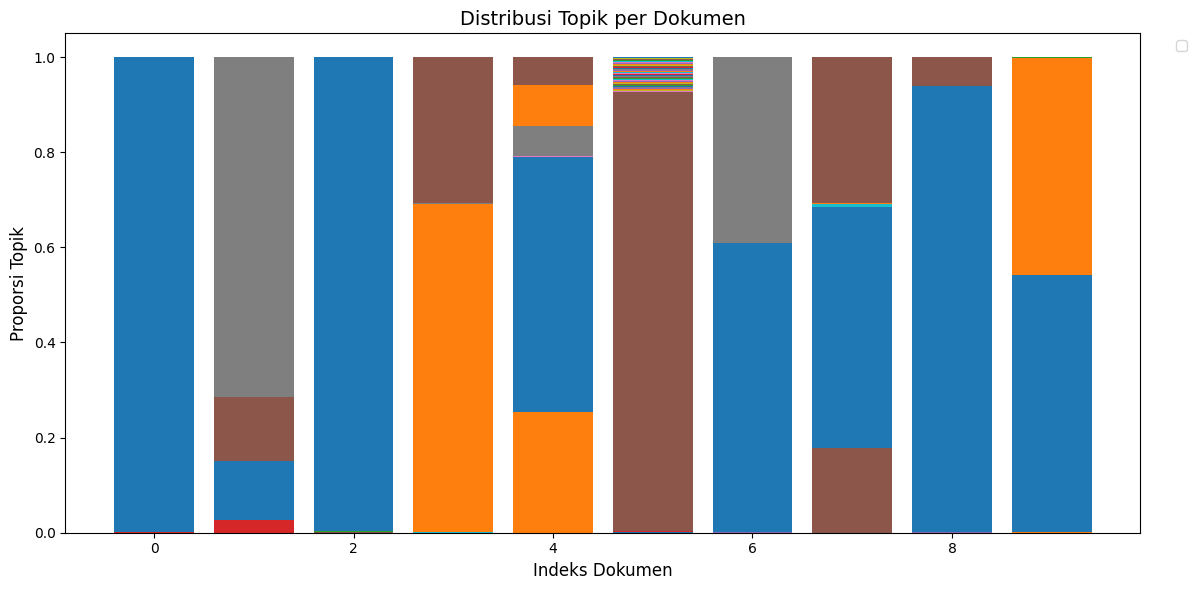

In [116]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]
n_docs = min(10, len(topic_distribution))
data = np.array([[prob for _, prob in topic_distribution[i]] for i in range(n_docs)])

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(n_docs)

for k in range(data.shape[1]):
    ax.bar(range(n_docs), data[:, k], bottom=bottom)
    bottom += data[:, k]

# Judul dan label sumbu
ax.set_title("Distribusi Topik per Dokumen", fontsize=14)
ax.set_xlabel("Indeks Dokumen", fontsize=12)
ax.set_ylabel("Proporsi Topik", fontsize=12)

# Tambahkan legenda di luar area plot agar rapi
ax.legend(bbox_to_anchor=(1.05, 1),)
plt.tight_layout()
plt.show()


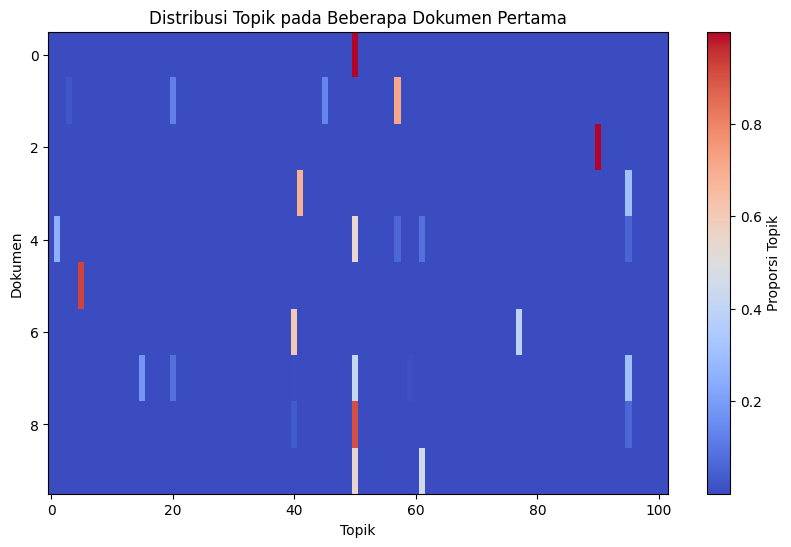

In [119]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

num_docs_to_show = 10
topic_matrix = np.array([[score for _, score in doc] for doc in topic_distribution[:num_docs_to_show]])

plt.figure(figsize=(10, 6))
plt.imshow(topic_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Proporsi Topik')
plt.xlabel('Topik')
plt.ylabel('Dokumen')
plt.title('Distribusi Topik pada Beberapa Dokumen Pertama')
plt.show()

In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df_result["isi_berita_clean"].astype(str)  # teks input
y = df_result["kategori_berita"].astype(str)   # label kategori

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


In [134]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Softmax Regression
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax_model.fit(X_train, y_train)
y_pred_softmax = softmax_model.predict(X_test)

In [135]:
def evaluasi_model(y_true, y_pred, model_name):
    print(f"\n=== Evaluasi Model: {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### 🔍 Evaluasi Model SVM ###

=== Evaluasi Model: SVM ===
Accuracy : 0.8722222222222222
Precision: 0.8779982363315696
Recall   : 0.8722222222222222

Classification Report:
                precision    recall  f1-score   support

      ekonomi       0.71      0.75      0.73        20
      hiburan       0.79      0.95      0.86        20
        hukum       0.95      0.95      0.95        20
internasional       1.00      0.90      0.95        20
   lingkungan       0.89      0.80      0.84        20
     olahraga       0.86      0.90      0.88        20
     otomotif       1.00      0.90      0.95        20
      politik       0.80      0.80      0.80        20
    sepakbola       0.90      0.90      0.90        20

     accuracy                           0.87       180
    macro avg       0.88      0.87      0.87       180
 weighted avg       0.88      0.87      0.87       180



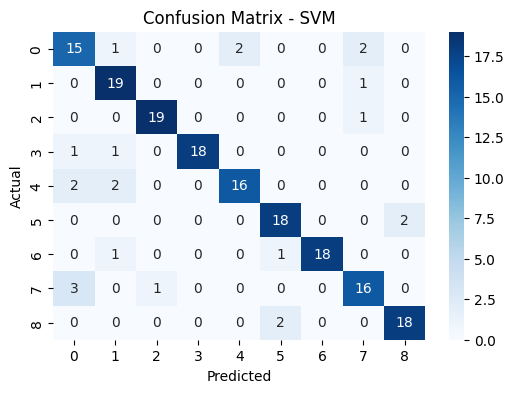

In [136]:
print("### 🔍 Evaluasi Model SVM ###")
evaluasi_model(y_test, y_pred_svm, "SVM")



### 🔍 Evaluasi Model Softmax Regression ###

=== Evaluasi Model: Softmax Regression ===
Accuracy : 0.8611111111111112
Precision: 0.8666514771777929
Recall   : 0.8611111111111112

Classification Report:
                precision    recall  f1-score   support

      ekonomi       0.68      0.75      0.71        20
      hiburan       0.79      0.95      0.86        20
        hukum       0.90      0.95      0.93        20
internasional       0.95      0.90      0.92        20
   lingkungan       0.88      0.70      0.78        20
     olahraga       0.86      0.90      0.88        20
     otomotif       1.00      0.90      0.95        20
      politik       0.84      0.80      0.82        20
    sepakbola       0.90      0.90      0.90        20

     accuracy                           0.86       180
    macro avg       0.87      0.86      0.86       180
 weighted avg       0.87      0.86      0.86       180



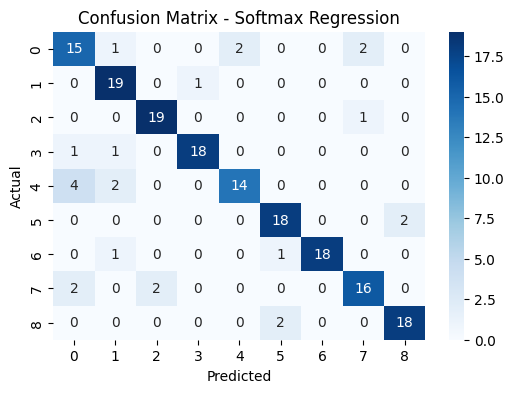

In [137]:
print("\n\n### 🔍 Evaluasi Model Softmax Regression ###")
evaluasi_model(y_test, y_pred_softmax, "Softmax Regression")

In [138]:
coherence_model = CoherenceModel(model=optimal_model, texts=texts, dictionary=dictionary, coherence='c_v')
coherence = coherence_model.get_coherence()
print("Coherence Score (c_v) untuk model terbaik:", coherence)

Coherence Score (c_v) untuk model terbaik: 0.39892290915768486
